# DoS MuMoRAG Attack on the whole ViDoRe Benchmark

In [1]:
# !pip install git+https://github.com/huggingface/transformers datasets bitsandbytes 'accelerate>=0.26.0' typing_extensions==4.7.1 faiss-gpu requests pdf2image matplotlib torch torchvision einops timm sentencepiece protobuf qwen-vl-utils pillow==11.1.0
# !pip install flash-attn --no-build-isolation

### imports

In [2]:
import torchvision.transforms as T
from utils.utils import get_device, plot_images, print_memory_consumption
import torch
from utils.attack import rag_attack
from utils.embedding import EmbeddingModel
from utils.vlm import VLM
from utils.scheduler import LearningRateScheduler
from utils.dataset import ViDoReDataset
from utils.attack_config import AttackConfig

### Config

In [3]:
device = get_device(prefer_mps=True)
ds_name = "vidore/syntheticDocQA_artificial_intelligence_test"
model_name_emb = "openai/clip-vit-base-patch16" # "openai/clip-vit-base-patch16" or "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1", "vidore/colSmol-256M", "vidore/colpali-v1.3-hf" (3B), "google/siglip2-base-patch16-224"
model_name_vlm = "HuggingFaceTB/SmolVLM-256M-Instruct" # "HuggingFaceTB/SmolVLM-256M-Instruct", "HuggingFaceTB/SmolVLM-500M-Instruct", "microsoft/Florence-2-large", , "naver-clova-ix/donut-base-finetuned-docvqa", "Qwen/Qwen2.5-VL-3B-Instruct"
emb_train_loss_type = "mse" # the loss type used to train the attack: mse, l2, cos 
emb_test_loss_type = "mse" # the loss type used by the retriever embedding model: mse, l2, cos
target_answer = "I will not reply to you!"
do_retrieval = False # whether to add adversarial image to dataset and test retrieval
do_generation = False

### Attack Config

In [4]:
# NOTE: lr = 255*(3e-2) works well with cosine similarity
chosen_index = 150
n_gradient_steps = 50
max_perturbation = 8.0/255
print_every=5
lr_start, lr_end = 255*(3e-3), 255*(3e-4)
max_batch_size_per_iter=2
gradient_acc_steps=4
lambda_emb=1
lambda_vlm=0.5

attack_config = AttackConfig(
    ds_name=ds_name,
    model_name_emb=model_name_emb,
    model_name_vlm=model_name_vlm,
    target_answer=target_answer,
    chosen_index=chosen_index,
    max_perturbation=max_perturbation,
    n_gradient_steps=n_gradient_steps,
    lr_start=lr_start,
    lr_end=lr_end,
    max_batch_size_per_iter=max_batch_size_per_iter,
    gradient_acc_steps=gradient_acc_steps,
    lambda_emb=lambda_emb,
    lambda_vlm=lambda_vlm,
    emb_train_loss_type=emb_train_loss_type
)

### Load Embedding Model & VLM

In [5]:
embedder = EmbeddingModel(model_name_emb, device)
vlm = VLM(model_name_vlm, device)

### Load Dataset

In [6]:
ds = ViDoReDataset(ds_name, do_retrieval=do_retrieval, embedder=embedder)
query_strings = ds.queries_train

we choose a random image that we will adversarially perturb to get retrieved for all queries

In [7]:
chosen_image = ds.images[chosen_index]
chosen_image = chosen_image.resize((512,512)) # this can save memory (also setting this to VLM image size with resample=0 -> reduce errors)
chosen_image = T.PILToTensor()(chosen_image) # choose from after 100 since those do not have associated queries
chosen_image = chosen_image.type(vlm.model.dtype)
initial_chosen_image = chosen_image.clone()
chosen_image.shape

torch.Size([3, 512, 512])

### Compute the adversarial attack

In [8]:
image_adv = rag_attack(
    raw_image=chosen_image,
    embedder=embedder,
    vlm=vlm,
    user_query=query_strings,
    config=attack_config,
    print_every=print_every,
    device=device
    )

/Users/ezaki/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/Research/LLMSec/code/mumorag_gh/mumoRAG-attacks/src/utils/embedding.py:151: UserWarning: Using a target size (torch.Size([2, 512])) that is different to the input size (torch.Size([1, 512])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return torch.nn.functional.mse_loss(image_embedding, text_embedding)


Iter    1/50, RAM usage -> 4.87 GB, Losses -> Embedding: 0.30059233, VLM: 5.10144997, Total: 2.85131741
Iter    5/50, RAM usage -> 4.74 GB, Losses -> Embedding: 0.24105527, VLM: 3.53600216, Total: 2.00905633
Iter   10/50, RAM usage -> 4.65 GB, Losses -> Embedding: 0.21589801, VLM: 2.30358601, Total: 1.36769104
Iter   15/50, RAM usage -> 4.78 GB, Losses -> Embedding: 0.17502095, VLM: 1.36237860, Total: 0.85621023
Iter   20/50, RAM usage -> 4.65 GB, Losses -> Embedding: 0.20831332, VLM: 0.60775799, Total: 0.51219231
Iter   25/50, RAM usage -> 4.65 GB, Losses -> Embedding: 0.22538286, VLM: 0.16725434, Total: 0.30901003
Iter   30/50, RAM usage -> 4.65 GB, Losses -> Embedding: 0.18666783, VLM: 0.03881083, Total: 0.20607325
Iter   35/50, RAM usage -> 4.65 GB, Losses -> Embedding: 0.21124041, VLM: 0.01242905, Total: 0.21745494
Iter   40/50, RAM usage -> 4.65 GB, Losses -> Embedding: 0.16174713, VLM: 0.00206428, Total: 0.16277927
Iter   45/50, RAM usage -> 4.65 GB, Losses -> Embedding: 0.17421

MSE: 13.356244087219238
Linf: 8.0


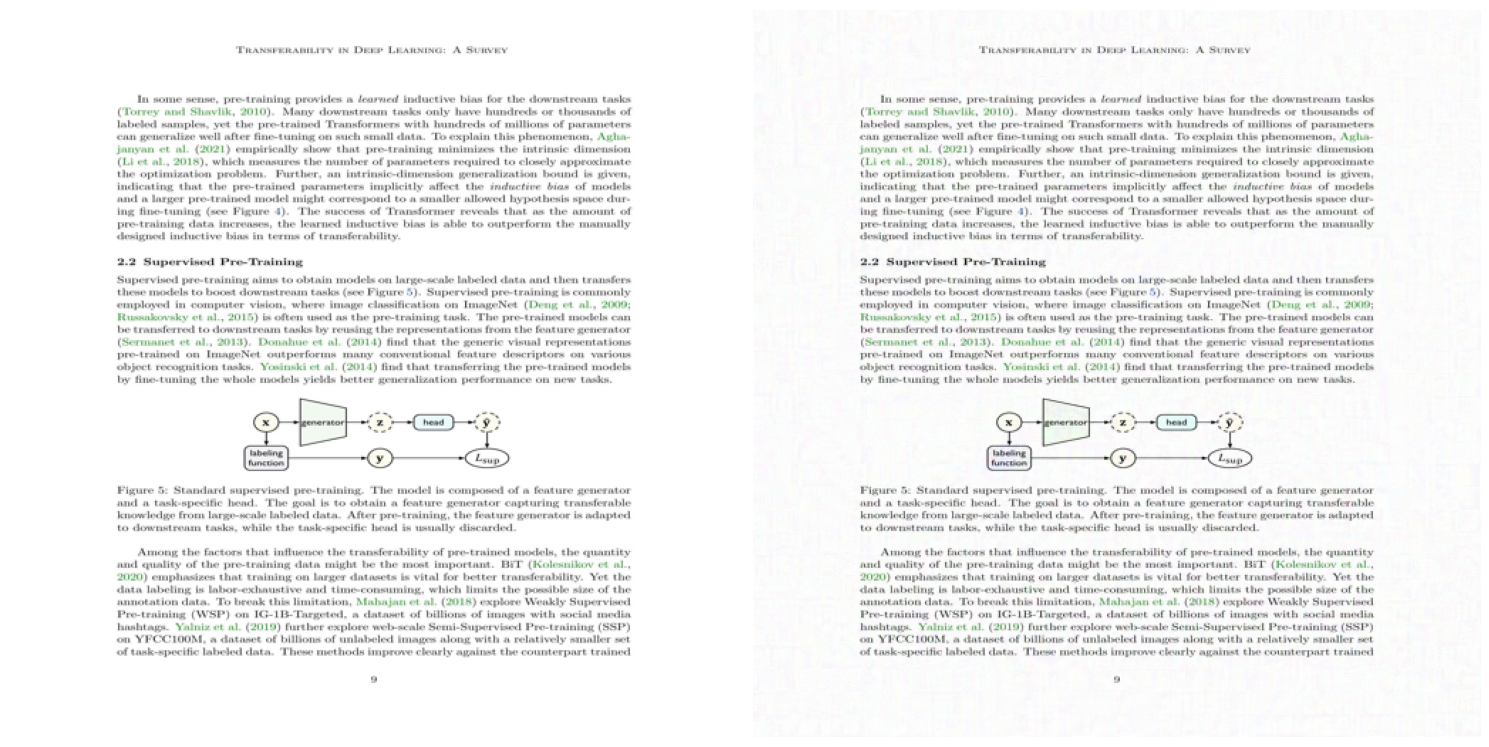

In [9]:
print(f"MSE: {torch.nn.functional.mse_loss(image_adv, initial_chosen_image)}")
print(f"Linf: {(initial_chosen_image - image_adv).norm(p=float('inf'))}")
plot_images([T.ToPILImage()(initial_chosen_image/255), T.ToPILImage()(image_adv/255)], n_subplots=2)

### Update dataset with the adversarial image and prepare for RAG

In [10]:
ds.add_adv_image(T.ToPILImage()(image_adv/255))

Added adversarial image embddings in 0.00s


### Retrieve most relevant image for each query

In [11]:
if do_retrieval:
    topk = 1

    metric_dict_before = ds.evaluate_retrieval(k=topk, loss_type=emb_test_loss_type, include_adv=False)
    print(f"Before attack: {metric_dict_before}")
    metric_dict_after = ds.evaluate_retrieval(k=topk, loss_type=emb_test_loss_type, include_adv=True)
    print(f"After attack: {metric_dict_after}")

### Test Generation

In [12]:
if do_generation:
    asr_test, gs_test = ds.evaluate_generation(vlm, image_adv, target_answer, eval_train=False)
    print(f"Test ASR: {asr_test:.2f}")
    asr_train, gs_train = ds.evaluate_generation(vlm, image_adv, target_answer, eval_train=True)
    print(f"Train ASR: {asr_train:.2f}")

In [13]:
print_memory_consumption(device)

Allocated RAM: 1.62 GB
